#HOSPITAL READMISSION PREDICTION
#Logistic Regression with L2 Regularization



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# 1. CREATE SYNTHETIC HOSPITAL DATA

In [ ]:
np.random.seed(42)

n = 500

age = np.random.randint(18, 90, n)

blood_pressure = np.random.randint(90, 180, n)

heart_rate = np.random.randint(60, 120, n)
previous_visits = np.random.randint(0, 11, n)
length_of_stay = np.random.randint(1, 16, n)
diagnosis_code = np.random.randint(1, 6, n)

# Create a risk score

In [ ]:
risk_score = (
    0.02 * age
    + 0.01 * blood_pressure
    + 0.01 * heart_rate
    + 0.30 * previous_visits
    + 0.20 * length_of_stay
    + 0.50 * diagnosis_code
)

# Add some randomness

In [ ]:
risk_score += np.random.normal(0, 1.5, n)

# Convert risk score into readmission

In [ ]:
readmitted = (risk_score > 7.5).astype(int)

# Create DataFrame

In [ ]:
data = pd.DataFrame({
    "age": age,
    "blood_pressure": blood_pressure,
    "heart_rate": heart_rate,
    "previous_visits": previous_visits,
    "length_of_stay": length_of_stay,
    "diagnosis_code": diagnosis_code,
    "readmitted": readmitted
})

# Save dataset as CSV

In [ ]:
data = pd.DataFrame({
    "age": age,
    "blood_pressure": blood_pressure,
    "heart_rate": heart_rate,
    "previous_visits": previous_visits,
    "length_of_stay": length_of_stay,
    "diagnosis_code": diagnosis_code,
    "readmitted": readmitted
})

# Save dataset as CSV

In [ ]:
data.to_csv("hospital_data.csv", index=False)

print("CSV file created successfully!")
print()

# Display first 5 records
print("First 5 records:")
print(data.head())

print()
print("Dataset shape:", data.shape)

print()
print("Class distribution:")
print(data["readmitted"].value_counts())

CSV file created successfully!

First 5 records:
   age  blood_pressure  heart_rate  previous_visits  length_of_stay  \
0   69             159         101                6              10   
1   32             120         108                3              12   
2   89             108          87                4               7   
3   78             150          90                0               8   
4   38             143         117                0               2   

   diagnosis_code  readmitted  
0               4           1  
1               2           0  
2               5           1  
3               4           1  
4               5           0  

Dataset shape: (500, 7)

Class distribution:
readmitted
1    278
0    222
Name: count, dtype: int64


# 2. LOAD CSV FILE

In [ ]:
data = pd.read_csv("hospital_data.csv")

# 3. SEPARATE FEATURES AND TARGET

In [ ]:
X = data.drop("readmitted", axis=1)

y = data["readmitted"]

# 4. TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [ ]:
print()
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 400
Testing samples: 100


# 5. FEATURE SCALING

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 6. LOGISTIC REGRESSION WITH L2

In [ ]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train model


In [ ]:

model.fit(X_train, y_train)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# 7. PREDICTIONS

In [ ]:
# Probability of readmission
y_probability = model.predict_proba(X_test)[:, 1]

# Convert probability to 0 or 1
threshold = 0.5

y_pred = (y_probability >= threshold).astype(int)

# 8. ROC-AUC

In [ ]:
auc = roc_auc_score(y_test, y_probability)

print()
print("==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("ROC-AUC:", round(auc, 4))


MODEL PERFORMANCE
ROC-AUC: 0.8949


# 9. CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print()
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[30 14]
 [ 4 52]]


# 10. CLASSIFICATION REPORT

In [ ]:
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.68      0.77        44
           1       0.79      0.93      0.85        56

    accuracy                           0.82       100
   macro avg       0.84      0.81      0.81       100
weighted avg       0.83      0.82      0.82       100



# 11. EXTRACT TP, FP, FN, TN

In [ ]:
tn, fp, fn, tp = cm.ravel()

print()
print("==============================")
print("CLINICAL ERROR ANALYSIS")
print("==============================")

print("True Negatives  :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives  :", tp)


CLINICAL ERROR ANALYSIS
True Negatives  : 30
False Positives : 14
False Negatives : 4
True Positives  : 52


# 12. ROC CURVE

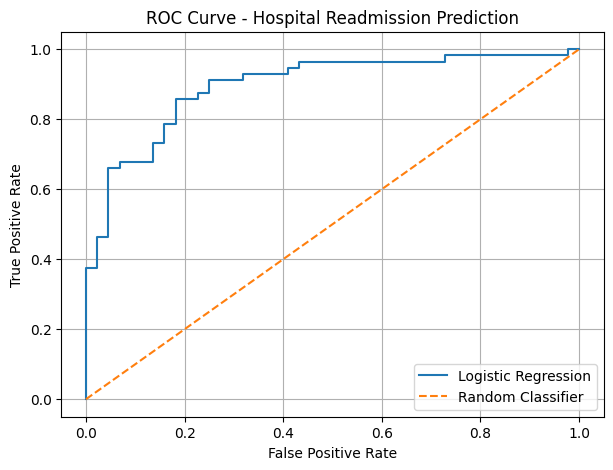

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()

plt.grid()

plt.show()

# 13. PREDICT A NEW PATIENT

In [ ]:
new_patient = [[
    70,     # age
    150,    # blood pressure
    95,     # heart rate
    5,      # previous visits
    10,     # length of stay
    4       # diagnosis code
]]

# Scale new patient
new_patient_scaled = scaler.transform(new_patient)

# Predict probability
new_probability = model.predict_proba(
    new_patient_scaled
)[0][1]

print()
print("==============================")
print("NEW PATIENT PREDICTION")
print("==============================")

print(
    "Readmission probability:",
    round(new_probability * 100, 2),
    "%"
)

if new_probability >= 0.5:
    print("Prediction: HIGH RISK of readmission")
else:
    print("Prediction: LOW RISK of readmission")


NEW PATIENT PREDICTION
Readmission probability: 90.3 %
Prediction: HIGH RISK of readmission


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
